# Introduction to deep learning

# Assignment 0
Pelagia Kalpakidou, 3744825
Myriana Miltiadous, 3699463
Elena Pitta, 3840220

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

In [3]:
train_in = pd.read_csv('train_in.csv',header=None).values
train_out=pd.read_csv('train_out.csv',header=None).values.flatten()
test_in=pd.read_csv('test_in.csv',header=None).values
test_out=pd.read_csv('test_out.csv',header=None).values.flatten()

## Task 1

### 1.1

In [4]:
# array to store the centers of each cloud corresponding to one digit
cds = np.zeros((10, 256))

In [5]:
#calculate centers for each cloud(digit=0,..,9)
for d in range(10):
    d_indices = np.where(train_out == d)[0]
    d_cloud = train_in[d_indices]
    cds[d] = np.mean(d_cloud, axis=0)

In [6]:
#distances between centers of the 10 clouds(for each digit)
c_dist=np.zeros([10,10])
for i in range(10):
    for j in range(10):
        c_dist[i][j]=np.linalg.norm(cds[i]-cds[j])

In [7]:
df = pd.DataFrame(c_dist, columns=range(10), index=range(10))
df

,0,1,2,3,4,5,6,7,8,9
0,0.000000,14.449608,9.334556,9.143734,10.769844,7.519296,8.154443,11.864555,9.907902,11.488875
1,14.449608,0.000000,10.125323,11.733233,10.173786,11.118800,10.614700,10.743154,10.086777,9.932094
2,9.334556,10.125323,0.000000,8.178285,7.932541,7.906796,7.331808,8.872531,7.077516,8.887748
3,9.143734,11.733233,8.178285,0.000000,9.087608,6.118750,9.302065,8.922401,7.020425,8.354350
4,10.769844,10.173786,7.932541,9.087608,0.000000,8.001517,8.782233,7.583012,7.380909,6.010408
5,7.519296,11.118800,7.906796,6.118750,8.001517,0.000000,6.698692,9.211954,6.967386,8.258538
6,8.154443,10.614700,7.331808,9.302065,8.782233,6.698692,0.000000,10.888237,8.587222,10.440004
7,11.864555,10.743154,8.872531,8.922401,7.583012,9.211954,10.888237,0.000000,8.467785,5.426474
8,9.907902,10.086777,7.077516,7.020425,7.380909,6.967386,8.587222,8.467785,0.000000,6.401166
9,11.488875,9.932094,8.887748,8.354350,6.010408,8.258538,10.440004,5.426474,6.401166,0.000000


In [8]:
#sorted dictionaries for each digit starting from the digit of which the center is closer to the specific digit that the dictionary is about 
#first dictionary is for zero...last dictionary for 9.
list_dict=[None]*10
for i in range(10):
    enum_arr = list(enumerate(c_dist[i]))
    # Sort the list of tuples based on the index
    sorted_enum_arr = sorted(enum_arr, key=lambda x: x[1])
    # Extract the elements from the sorted list of tuples
    sorted_arr = [x[0] for x in sorted_enum_arr]
    result_dict = {}
    for value1, value2 in zip(sorted_arr, sorted(c_dist[i])):
        result_dict[value1] = value2
    list_dict[i]=result_dict
    print(result_dict)

{0: 0.0, 5: 7.519296259597183, 6: 8.154443125778972, 3: 9.143733671882783, 2: 9.334555870229641, 8: 9.90790173732039, 4: 10.769844437633486, 9: 11.488874937417041, 7: 11.864555054634078, 1: 14.44960796590658}
{1: 0.0, 9: 9.932093699343712, 8: 10.086776773038181, 2: 10.125322577096668, 4: 10.173786431281785, 6: 10.614700366283566, 7: 10.743153673524732, 5: 11.118800407467436, 3: 11.733232901831071, 0: 14.44960796590658}
{2: 0.0, 8: 7.077516177863561, 6: 7.33180753932081, 5: 7.906796320949824, 4: 7.932541482770051, 3: 8.17828488564782, 7: 8.872531069307183, 9: 8.88774785200019, 0: 9.334555870229641, 1: 10.125322577096668}
{3: 0.0, 5: 6.118750020921418, 8: 7.020424894700361, 2: 8.17828488564782, 9: 8.354350120111869, 7: 8.922400934698304, 4: 9.087607799539475, 0: 9.143733671882783, 6: 9.302064730092098, 1: 11.733232901831071}
{4: 0.0, 9: 6.0104079308959975, 8: 7.380908991053923, 7: 7.583012282564445, 2: 7.932541482770051, 5: 8.001517414291122, 6: 8.78223264756089, 3: 9.087607799539475, 1:

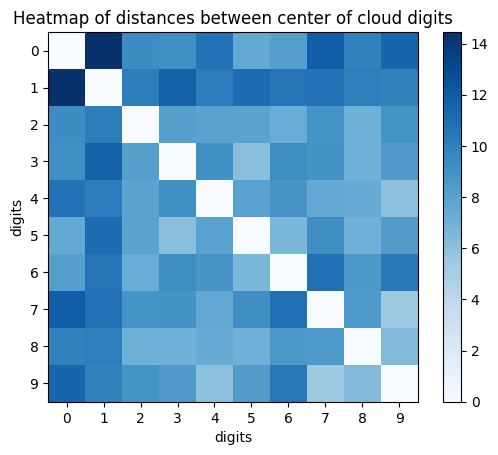

In [9]:
#Heatmap for the distances between the digits centers
plt.imshow(df, cmap='Blues', interpolation='nearest')
plt.xticks(np.arange(10))
plt.yticks(np.arange(10))
plt.colorbar() 
plt.title('Heatmap of distances between center of cloud digits')
plt.xlabel('digits')
plt.ylabel('digits')
plt.show()

### 1.2

In [10]:
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from matplotlib import offsetbox
import matplotlib.patheffects as PathEffects
import seaborn as sns
import plotly.graph_objects as go
%matplotlib inline

#### PCA

In [11]:
#Preprocess the Dataset
std_scaler = StandardScaler()
scaled_df = std_scaler.fit_transform(test_in)

In [12]:
#Perform PCA on the Preprocessed Dataset
pca = PCA(n_components=2)
X_pca=pca.fit_transform(scaled_df)

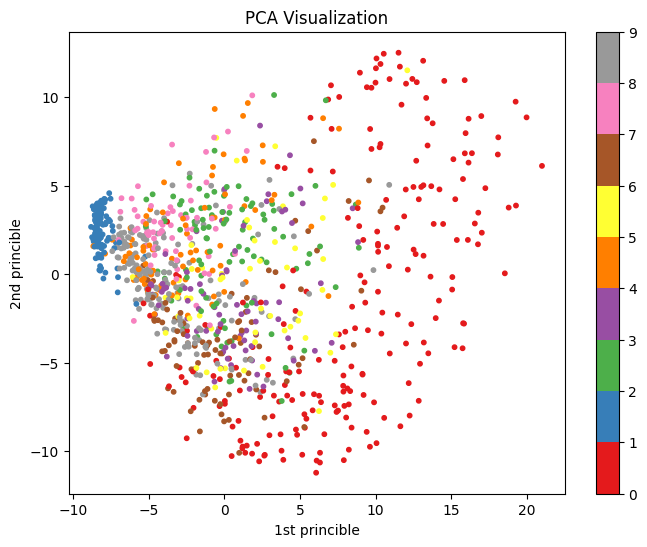

In [13]:
#visualize PCA
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=test_out, cmap='Set1', s=10)
plt.colorbar()
plt.title('PCA Visualization')
plt.xlabel('1st princible')
plt.ylabel('2nd princible')
plt.show()

#### U-MAP

In [14]:
import umap
#perform UMAP
reducer = umap.UMAP()
reducer.fit(train_in)
embedding = reducer.transform(train_in)
assert(np.all(embedding == reducer.embedding_))
embedding.shape

C:\Users\myria\AppData\Roaming\Python\Python38\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(1707, 2)

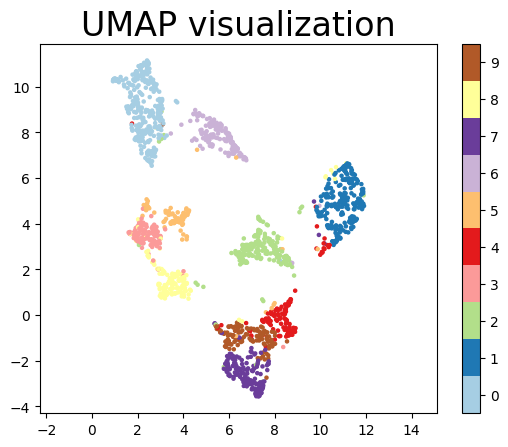

In [15]:
#visualize data
plt.scatter(embedding[:, 0], embedding[:, 1], c=train_out, cmap='Paired', s=5)
plt.gca().set_aspect('equal', 'datalim')
plt.colorbar(boundaries=np.arange(11)-0.5).set_ticks(np.arange(10))
plt.title('UMAP visualization', fontsize=24);


#### T-SNE

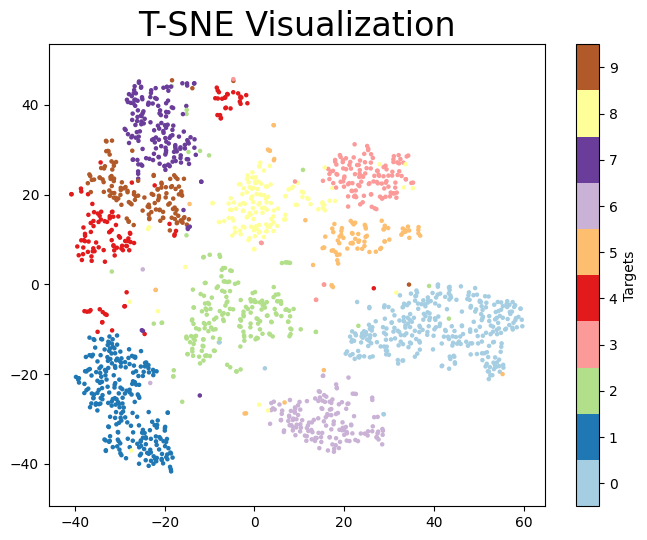

In [37]:
# Perform TSNE
tsne = TSNE(n_components=2, random_state=42)
x_transformed = tsne.fit_transform(train_in)
tsne_df = pd.DataFrame(np.column_stack((x_transformed, train_out)), columns=['X', 'Y', "Targets"])
tsne_df.loc[:, "Targets"] = tsne_df.Targets.astype(int)
# visualize T-SNE
plt.figure(figsize=(8, 6))
scatter = plt.scatter(tsne_df['X'], tsne_df['Y'], c=tsne_df['Targets'], cmap='Paired', s=5)
plt.gca().set_aspect('equal', 'datalim')
cbar = plt.colorbar(scatter, boundaries=np.arange(tsne_df['Targets'].min()-0.5, tsne_df['Targets'].max()+1.5), ticks=np.arange(tsne_df['Targets'].min(), tsne_df['Targets'].max()+1))
cbar.set_label('Targets')
plt.title('T-SNE Visualization', fontsize=24)
plt.show()

### 1.3

In [18]:
#implement nearest mean classifier

class nearest_mean_classifier:
    def __init__(self, data_in, data_out, cds):
        self.data_in = data_in
        self.data_out = data_out
        self.cds = cds
        self.classified_num=np.zeros(len(self.data_in))

    def classifier_accuracy(self):
        #calculate accuracy
        test_dist = np.zeros([len(self.data_in), 10])
        s = np.zeros(len(self.data_in))

        for i in range(len(self.data_in)):
            for j in range(10):
                test_dist[i][j] = np.linalg.norm(self.data_in[i] - self.cds[j])
            self.classified_num[i] = test_dist[i].argmin()
            if self.classified_num[i] == self.data_out[i]:
                s[i] = 1

        accuracy = np.mean(s)
        return accuracy

    def missclassifications(self):
        #calculate missclassifications per digit and their corresponding percentages
        incorrectly_classified_indices = np.where(self.data_out != self.classified_num)[0]
        unique_elements, counts = np.unique(self.data_out[incorrectly_classified_indices], return_counts=True)
        missclassification_distribution = dict(zip(unique_elements, counts))

        total_sum = sum(missclassification_distribution.values())
        percentage_dict = {key: (value / total_sum) * 100 for key, value in missclassification_distribution.items()}
        sorted_percentage_dict = dict(sorted(percentage_dict.items(), key=lambda item: item[1], reverse=True))

        return missclassification_distribution, sorted_percentage_dict




In [19]:
#run the nearest mean classifier for train data

classifier_train = nearest_mean_classifier(train_in, train_out, cds)

accuracy_train = classifier_train.classifier_accuracy()

print(f"Train Accuracy: {accuracy_train}%")
missclassifications_train, sorted_percentages_train = classifier_train.missclassifications()
print("\nMisclassifications per digit for train set:")
print(missclassifications_train)
print("\nPercentage of misclassifications per digit for train set:")
print(sorted_percentages_train)

Train Accuracy: 0.8635032220269478%

Misclassifications per digit for train set:
{0: 48, 2: 35, 3: 11, 4: 27, 5: 21, 6: 22, 7: 26, 8: 23, 9: 20}

Percentage of misclassifications per digit for train set:
{0: 20.600858369098713, 2: 15.021459227467812, 4: 11.587982832618025, 7: 11.158798283261802, 8: 9.871244635193133, 6: 9.44206008583691, 5: 9.012875536480687, 9: 8.583690987124463, 3: 4.721030042918455}


In [20]:
#run the nearest mean classifier for test data
classifier_test = nearest_mean_classifier(test_in, test_out, cds)

accuracy_test = classifier_test.classifier_accuracy()

print(f"Test Accuracy: {accuracy_test}%")
missclassifications_test, sorted_percentages_test = classifier_test.missclassifications()
print("\nMisclassifications per digit for test set:")
print(missclassifications_test)
print("\nPercentage of misclassifications per digit for test set:")
print(sorted_percentages_test)

Test Accuracy: 0.804%

Misclassifications per digit for test set:
{0: 46, 1: 1, 2: 32, 3: 18, 4: 17, 5: 17, 6: 12, 7: 14, 8: 19, 9: 20}

Percentage of misclassifications per digit for test set:
{0: 23.46938775510204, 2: 16.3265306122449, 9: 10.204081632653061, 8: 9.693877551020408, 3: 9.183673469387756, 4: 8.673469387755102, 5: 8.673469387755102, 7: 7.142857142857142, 6: 6.122448979591836, 1: 0.5102040816326531}


### 1.4

In [21]:
from __future__ import print_function
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

In [22]:
# take some data from train to use for validation
(trainData, valData, trainLabels, valLabels) = train_test_split(train_in, train_out,
	test_size=0.1, random_state=84)

In [23]:
#Train classifier to find the optimal value of k:


kVals = range(1, 30, 2)
accuracies = []

# loop over various `k`s
for k in range(1, 30, 2):
	# train the k-Nearest Neighbor classifier with the current value of `k`
	model = KNeighborsClassifier(n_neighbors=k)
	model.fit(trainData, trainLabels)

	# evaluate the model and update the accuracies list
	score = model.score(valData, valLabels)
	print("k=%d, accuracy=%.2f%%" % (k, score * 100))
	accuracies.append(score)

# find the value of k that has the largest accuracy
i = int(np.argmax(accuracies))
print("k=%d achieved highest accuracy of %.2f%% on validation data" % (kVals[i],
	accuracies[i] * 100))

k=1, accuracy=94.74%
k=3, accuracy=93.57%
k=5, accuracy=91.23%
k=7, accuracy=90.64%
k=9, accuracy=89.47%
k=11, accuracy=89.47%
k=13, accuracy=90.06%
k=15, accuracy=88.89%
k=17, accuracy=88.89%
k=19, accuracy=88.30%
k=21, accuracy=87.13%
k=23, accuracy=87.13%
k=25, accuracy=86.55%
k=27, accuracy=86.55%
k=29, accuracy=86.55%
k=1 achieved highest accuracy of 94.74% on validation data


In [24]:
# re-train the classifier using the best k (k=1)
model = KNeighborsClassifier(n_neighbors=kVals[i])
model.fit(trainData, trainLabels)

KNeighborsClassifier(n_neighbors=1)

In [25]:
#final classification report with the accuracy of the classifier on training data for all the digits
predictions_train = model.predict(train_in)
print("EVALUATION ON TRAINING DATA")
print(classification_report(train_out, predictions_train))

EVALUATION ON TRAINING DATA
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       319
           1       0.99      1.00      0.99       252
           2       1.00      0.98      0.99       202
           3       0.99      0.99      0.99       131
           4       1.00      0.98      0.99       122
           5       1.00      1.00      1.00        88
           6       1.00      1.00      1.00       151
           7       0.99      1.00      1.00       166
           8       0.98      0.99      0.99       144
           9       0.99      1.00      1.00       132

    accuracy                           0.99      1707
   macro avg       0.99      0.99      0.99      1707
weighted avg       0.99      0.99      0.99      1707



In [26]:
#final classification report with the accuracy of the classifier on test data for all the digits
predictions_test = model.predict(test_in)
print("EVALUATION ON TESTING DATA")
print(classification_report(test_out, predictions_test))

EVALUATION ON TESTING DATA
              precision    recall  f1-score   support

           0       0.93      0.98      0.95       224
           1       0.96      0.98      0.97       121
           2       0.92      0.82      0.87       101
           3       0.84      0.91      0.87        79
           4       0.94      0.87      0.90        86
           5       0.93      0.76      0.84        55
           6       0.94      0.93      0.94        90
           7       0.83      0.92      0.87        64
           8       0.91      0.84      0.87        92
           9       0.88      0.95      0.92        88

    accuracy                           0.91      1000
   macro avg       0.91      0.90      0.90      1000
weighted avg       0.91      0.91      0.91      1000



Text(0.5, 1.0, 'Nearest Mean Classifier')

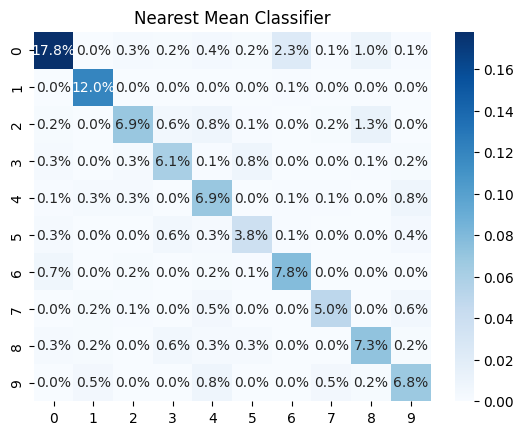

In [40]:
from sklearn import metrics
#confusion matrix for nearest mean classifier performance on test set
confusion_matrix_nmc = metrics.confusion_matrix(test_out, classifier_test.classified_num)
confusion_matrix_nmc
sns.heatmap(confusion_matrix_nmc/np.sum(confusion_matrix_nmc), annot=True, 
            fmt='.1%', cmap='Blues')
plt.title('Nearest Mean Classifier')

Text(0.5, 1.0, 'KNN Classifier')

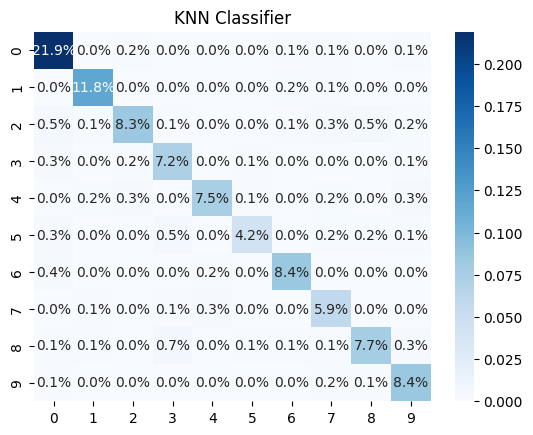

In [39]:
#confusion matrix for KNN classifier performance on test set
confusion_matrix_knn = metrics.confusion_matrix(test_out, predictions_test)
confusion_matrix_knn
sns.heatmap(confusion_matrix_knn/np.sum(confusion_matrix_knn), annot=True, 
            fmt='.1%', cmap='Blues')
plt.title('KNN Classifier')